In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tabulate import tabulate

plt.style.use("../auri.mplstyle")

pd.options.display.unicode.east_asian_width = True

In [4]:
parquet_path = Path("../data/processed/주건축물_검증규칙.parquet")
df_orig = pd.read_parquet(parquet_path)
print(f"Loaded shape: {df_orig.shape}")
df_orig.head()

Loaded shape: (7364967, 38)


,관리_건축물대장_PK,관리_상위_건축물대장_PK,단독,대지_위치,시군구_코드,법정동_코드,주_용도_코드,주_용도_코드_명,기타_용도,대지_면적(㎡),...,건폐율_재계산,건폐율_차이,기존19,용적률_재계산,용적률_차이,기존20,신규01,연면적_상한,신규02,신규03
0,10021950,10021363,False,서울특별시 종로구 숭인동 201번지,11110,17500,01000,단독주택,주택,NaN,...,NaN,NaN,None,NaN,NaN,None,None,NaN,None,False
1,10021957,10021366,False,서울특별시 종로구 숭인동 569번지,11110,17500,02000,공동주택,아파트,513.0,...,44.409357,-0.009357,False,128.625731,152.414269,True,False,2107.74,False,False
2,10021958,10021366,False,서울특별시 종로구 숭인동 569번지,11110,17500,02000,공동주택,연립주택,NaN,...,NaN,NaN,None,NaN,NaN,None,None,NaN,None,False
3,10021973,10021373,False,서울특별시 종로구 숭인동 1132번지,11110,17500,04000,제2종근린생활시설,영업,NaN,...,NaN,NaN,None,NaN,NaN,None,None,NaN,None,False
4,10021974,10021373,False,서울특별시 종로구 숭인동 1132번지,11110,17500,04000,제2종근린생활시설,근린생활시설,NaN,...,NaN,NaN,None,NaN,NaN,None,None,NaN,None,False


In [5]:
df_orig.dtypes

관리_건축물대장_PK               object
관리_상위_건축물대장_PK          object
단독                               bool
대지_위치                        object
시군구_코드                      object
법정동_코드                      object
주_용도_코드                     object
주_용도_코드_명                  object
기타_용도                        object
대지_면적(㎡)                   float64
건축_면적(㎡)                   float64
건폐_율(%)                      float64
연면적(㎡)                      float64
용적_률_산정_연면적(㎡)         float64
용적_률(%)                      float64
높이(m)                         float64
지상_층_수                        int32
지하_층_수                        int32
사용승인_일                      object
총괄_대지_면적(㎡)              float64
총괄_건축_면적(㎡)              float64
총괄_건폐_율(%)                 float64
총괄_연면적(㎡)                 float64
총괄_용적_률_산정_연면적(㎡)    float64
총괄_용적_률(%)                 float64
총괄_주_건축물_수               float64
기존14                           object
기존16                           object
건폐율_재계산                

In [9]:
# 검증규칙 통과한 건축물만 선택
cols = ["기존14", "기존16", "기존19", "기존20", "신규01", "신규02", "신규03"]

df_filtered = df_orig[(df_orig[cols] != True).all(axis=1)]
df_filtered.head()

,관리_건축물대장_PK,관리_상위_건축물대장_PK,단독,대지_위치,시군구_코드,법정동_코드,주_용도_코드,주_용도_코드_명,기타_용도,대지_면적(㎡),...,건폐율_재계산,건폐율_차이,기존19,용적률_재계산,용적률_차이,기존20,신규01,연면적_상한,신규02,신규03
0,10021950,10021363,False,서울특별시 종로구 숭인동 201번지,11110,17500,01000,단독주택,주택,NaN,...,NaN,NaN,None,NaN,NaN,None,None,NaN,None,False
2,10021958,10021366,False,서울특별시 종로구 숭인동 569번지,11110,17500,02000,공동주택,연립주택,NaN,...,NaN,NaN,None,NaN,NaN,None,None,NaN,None,False
3,10021973,10021373,False,서울특별시 종로구 숭인동 1132번지,11110,17500,04000,제2종근린생활시설,영업,NaN,...,NaN,NaN,None,NaN,NaN,None,None,NaN,None,False
4,10021974,10021373,False,서울특별시 종로구 숭인동 1132번지,11110,17500,04000,제2종근린생활시설,근린생활시설,NaN,...,NaN,NaN,None,NaN,NaN,None,None,NaN,None,False
5,10021980,10021376,False,서울특별시 종로구 숭인동 1419번지,11110,17500,04000,제2종근린생활시설,"근린생활시설, 근린생활시설(판매시설)",NaN,...,NaN,NaN,None,NaN,NaN,None,None,NaN,None,False


In [10]:
df_filtered.shape

(6810154, 38)

In [11]:
df_filtered.dtypes

관리_건축물대장_PK               object
관리_상위_건축물대장_PK          object
단독                               bool
대지_위치                        object
시군구_코드                      object
법정동_코드                      object
주_용도_코드                     object
주_용도_코드_명                  object
기타_용도                        object
대지_면적(㎡)                   float64
건축_면적(㎡)                   float64
건폐_율(%)                      float64
연면적(㎡)                      float64
용적_률_산정_연면적(㎡)         float64
용적_률(%)                      float64
높이(m)                         float64
지상_층_수                        int32
지하_층_수                        int32
사용승인_일                      object
총괄_대지_면적(㎡)              float64
총괄_건축_면적(㎡)              float64
총괄_건폐_율(%)                 float64
총괄_연면적(㎡)                 float64
총괄_용적_률_산정_연면적(㎡)    float64
총괄_용적_률(%)                 float64
총괄_주_건축물_수               float64
기존14                           object
기존16                           object
건폐율_재계산                

### 무차원 변수 산출

건축물의 규모에 비례하지 않는 변수(무차원수)를 산출하기 위하여 면적 관련 변수의 차원 분석을 시행.

|이름|차원|
|----|----|
|대지면적|[면적] = [길이]²|
|건축면적|[면적] = [길이]²|
|지상 층수|[층수] = [개수]|
|지하 층수|[층수] = [개수]|
|연면적|[면적][층수] = [길이]²[개수]|
|용적률 산정용 연면적|[면적][층수] = [길이]²[개수]|

각 변수의 비율을 구하여 무차원 변수를 산출하고, 클러스터링 및 기계학습에 활용.

|이름|정의|차원|
|----|----|----|
|건폐율 (재산출)|건축면적/대지면적|[면적]/[면적] = 1|
|층별 용적률|연면적/(대지면적×(지상 층수+지하 층수))|[면적][층수]/[면적][층수] = 1|
|지상층별 용적률|용적률 산정용 연면적/(대지면적×지상 층수)|[면적][층수]/[면적][층수] = 1|
|충만률|용적률 산정용 연면적/(건축면적×지상 층수)|[면적][층수]/[면적][층수] = 1|

In [ ]:
# 우선 COALESCE 적용
대지면적 = df_filtered["대지_면적(㎡)"].fillna(df_filtered["총괄_대지_면적(㎡)"])
건축면적 = df_filtered["건축_면적(㎡)"].fillna(df_filtered["총괄_건축_면적(㎡)"])

df_dimensionless = pd.DataFrame(
    {
        "관리_건축물대장_PK": df_filtered["관리_건축물대장_PK"],
        # 건폐율 (재산출) = 건축면적 / 대지면적
        "건폐율": 건축면적 / 대지면적,
        # 층별 용적률 = 연면적 / (대지면적 × (지상층수+지하층수))
        "층별_용적률": df_filtered["연면적(㎡)"]
        / (대지면적 * (df_filtered["지상_층_수"] + df_filtered["지하_층_수"])),
        # 지상층별 용적률 = 용적률 산정용 연면적 / (대지면적 × 지상층수)
        "지상층별_용적률": df_filtered["용적_률_산정_연면적(㎡)"]
        / (대지면적 * df_filtered["지상_층_수"]),
        # 충만률 = 용적률 산정용 연면적 / (건축면적 × 지상층수)
        "충만률": df_filtered["용적_률_산정_연면적(㎡)"]
        / (건축면적 * df_filtered["지상_층_수"]),
    }
)

# 무한대/NaN 정리
df_dimensionless = df_dimensionless.replace(
    [pd.NA, float("inf"), -float("inf")], np.nan
)
# df_dimensionless = df_dimensionless.fillna(-999)

In [35]:
df_dimensionless.dtypes

관리_건축물대장_PK     object
건폐율                float64
층별_용적률           float64
지상층별_용적률       float64
충만률                float64
dtype: object

In [ ]:
with pd.option_context("display.float_format", "{:.4f}".format):
    display(df_dimensionless.describe())

,건폐율,층별_용적률,지상층별_용적률,충만률
count,4670237.0000,4698437.0000,4611103.0000,6419831.0000
mean,0.3107,0.2740,0.2724,0.9739
std,2.6443,0.4993,0.3356,47.7333
min,0.0000,0.0000,-0.0093,0.0000
25%,0.1189,0.1078,0.1076,0.8921
50%,0.2510,0.2275,0.2262,1.0000
75%,0.5268,0.4385,0.4376,1.0000
max,4875.0850,381.6810,373.5833,66603.0000


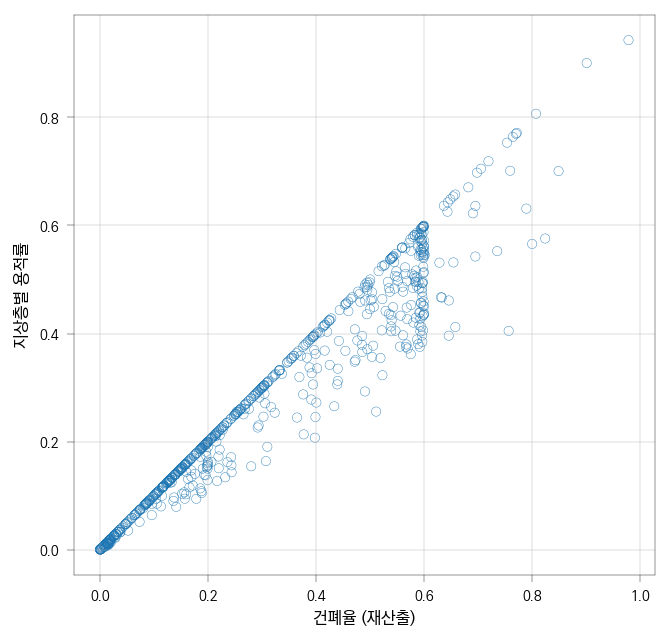

In [39]:
sampled = df_dimensionless.sample(n=1000, random_state=1106).copy()

# Scatterplot
plt.figure(figsize=(5, 5))
plt.scatter(
    sampled["건폐율"],
    sampled["지상층별_용적률"],
    edgecolors="tab:blue",
    facecolors="none",
    s=20,
)

plt.gca().set_aspect("equal")
plt.xlabel("건폐율 (재산출)")
plt.ylabel("지상층별 용적률")
plt.grid(True)

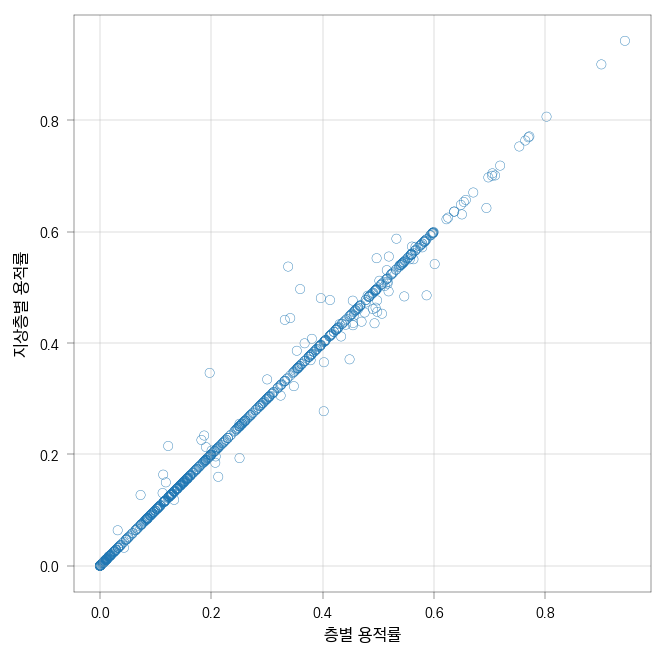

In [41]:
sampled = df_dimensionless.sample(n=1000, random_state=1106).copy()

# Scatterplot
plt.figure(figsize=(5, 5))
plt.scatter(
    sampled["층별_용적률"],
    sampled["지상층별_용적률"],
    edgecolors="tab:blue",
    facecolors="none",
    s=20,
)

plt.gca().set_aspect("equal")
plt.xlabel("층별 용적률")
plt.ylabel("지상층별 용적률")
plt.grid(True)

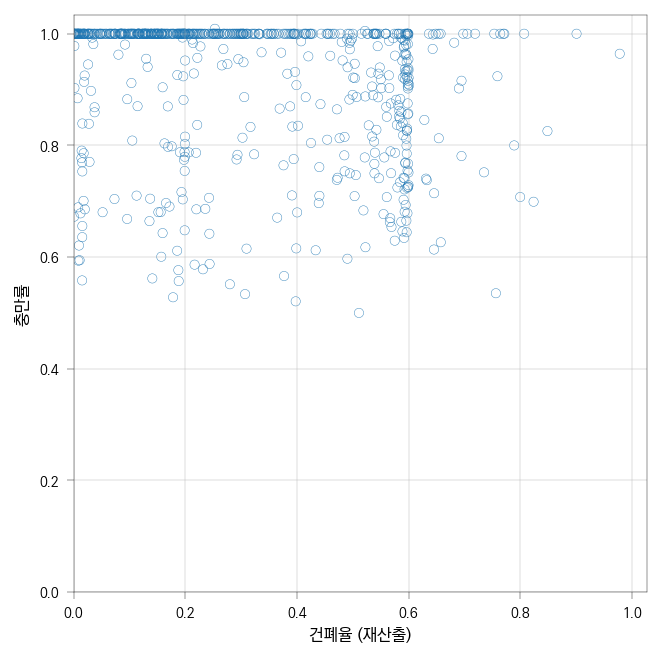

In [43]:
sampled = df_dimensionless.sample(n=1000, random_state=1106).copy()

# Scatterplot
plt.figure(figsize=(5, 5))
plt.scatter(
    sampled["건폐율"],
    sampled["충만률"],
    edgecolors="tab:blue",
    facecolors="none",
    s=20,
)

plt.xlim(left=0)
plt.ylim(bottom=0)
plt.gca().set_aspect("equal")
plt.xlabel("건폐율 (재산출)")
plt.ylabel("충만률")
plt.grid(True)

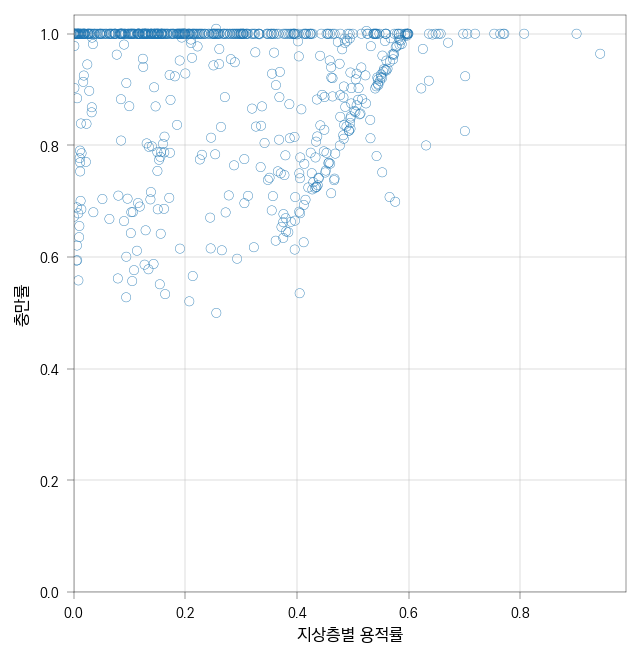

In [44]:
sampled = df_dimensionless.sample(n=1000, random_state=1106).copy()

# Scatterplot
plt.figure(figsize=(5, 5))
plt.scatter(
    sampled["지상층별_용적률"],
    sampled["충만률"],
    edgecolors="tab:blue",
    facecolors="none",
    s=20,
)

plt.xlim(left=0)
plt.ylim(bottom=0)
plt.gca().set_aspect("equal")
plt.xlabel("지상층별 용적률")
plt.ylabel("충만률")
plt.grid(True)

### K-means

빅데이터이므로 MiniBatchKMeans 사용.

elbow 방법으로 적절한 클러스터 개수(K) 탐색.

In [ ]:
import numpy as np
from sklearn.cluster import MiniBatchKMeans
from sklearn.utils import check_random_state


def minibatch_inertia_curve(
    X, ks, *, batch_size=2048, random_state=0, repeats=3, max_iter=100
):
    rng = check_random_state(random_state)
    inertias = []
    for k in ks:
        vals = []
        for r in range(repeats):
            mbk = MiniBatchKMeans(
                n_clusters=k,
                random_state=rng.randint(0, 2**31 - 1),
                batch_size=batch_size,
                max_iter=max_iter,
                n_init="auto",
            )
            mbk.fit(X)
            vals.append(mbk.inertia_)
        inertias.append(float(np.median(vals)))
    return np.asarray(inertias)


def kneedle_elbow(ks, inertias):
    # Normalize to [0,1] and flip so larger is better
    x = (np.array(ks) - ks[0]) / (ks[-1] - ks[0])
    y = (inertias.max() - inertias) / (inertias.max() - inertias.min() + 1e-12)

    # Line between endpoints: y = x  (after the above normalization)
    # Distance from each point to the line
    d = (y - x) / np.sqrt(2.0)
    idx = int(np.argmax(d))
    return ks[idx], idx, d


In [46]:
df_dimensionless.columns

Index(['관리_건축물대장_PK', '건폐율', '층별_용적률', '지상층별_용적률',
       '충만률'], dtype='object')

In [47]:
X = (
    df_dimensionless[["건폐율", "층별_용적률", "지상층별_용적률", "충만률"]]
    .fillna(-999)
    .to_numpy()
)

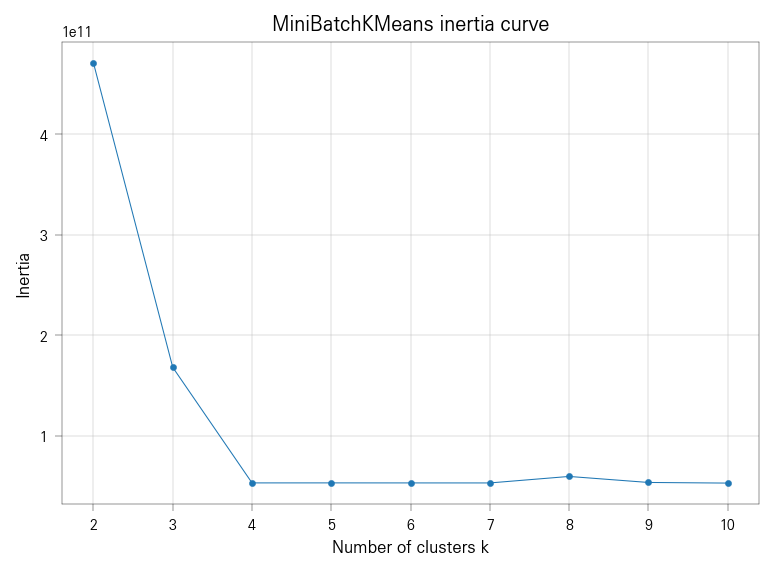

In [ ]:
ks = np.arange(2, 11)  # pick a sensible range
inertias = minibatch_inertia_curve(X, ks, batch_size=2048, repeats=5)
plt.figure(figsize=(6, 4))
plt.plot(ks, inertias, marker="o")
plt.xlabel("Number of clusters k")
plt.ylabel("Inertia")
plt.title("MiniBatchKMeans inertia curve")
plt.grid(True)
plt.show()


In [50]:
k_star, idx, _ = kneedle_elbow(ks, inertias)
print("Elbow at k =", k_star)

Elbow at k = 4


4개가 적절한 것으로 판단됨.

In [ ]:
feature_names = ["건폐율", "층별_용적률", "지상층별_용적률", "충만률"]
k = 4  # from above elbow analysis

km = MiniBatchKMeans(
    n_clusters=k,
    random_state=1106,
).fit(X)

labels = km.labels_
inertia = float(km.inertia_)
sizes = np.bincount(labels, minlength=k)

# centers in original feature scale
centers = km.cluster_centers_
centers_df = pd.DataFrame(
    centers, columns=feature_names, index=[f"cluster_{i}" for i in range(k)]
)

# ---- per-cluster stats (original scale) ----
df_orig = pd.DataFrame(X, columns=feature_names)
df_orig["_cluster"] = labels

means = df_orig.groupby("_cluster").mean(numeric_only=True)
stds = df_orig.groupby("_cluster").std(numeric_only=True, ddof=0)
mins = df_orig.groupby("_cluster").min(numeric_only=True)
maxs = df_orig.groupby("_cluster").max(numeric_only=True)

print("=== MiniBatchKMeans (k=4) Summary ===")
print(f"Inertia: {inertia:,.3f}")
print("Cluster sizes:", dict((f"cluster_{i}", int(sizes[i])) for i in range(k)))
print("\nCluster centers (original scale):")
print(centers_df.round(4))
print("\nPer-cluster means (original scale):")
print(means.add_prefix("mean_").round(4))
print("\nPer-cluster stds (original scale):")
print(stds.add_prefix("std_").round(4))
print("\nPer-cluster mins / maxs (original scale):")
print(mins.add_prefix("min_").round(4))
print(maxs.add_prefix("max_").round(4))

=== MiniBatchKMeans (k=4) Summary ===
Inertia: 53,413,406,244.705
Cluster sizes: {'cluster_0': 104799, 'cluster_1': 4596028, 'cluster_2': 1823804, 'cluster_3': 285523}

Cluster centers (original scale):
             건폐율  층별_용적률  지상층별_용적률    충만률
cluster_0 -306.8456       0.3857        -903.3061 -999.0000
cluster_1    0.3077      -0.4514           0.2736    0.9114
cluster_2 -999.0000    -999.0000        -999.0000    1.5760
cluster_3 -997.8249    -997.8246        -983.7208 -999.0000

Per-cluster means (original scale):
          mean_건폐율  mean_층별_용적률  mean_지상층별_용적률  mean_충만률
_cluster                                                                  
0           -295.8865            0.4182             -903.6984    -999.0000
1              0.3072           -0.2489                0.2714       0.9686
2           -999.0000         -999.0000             -999.0000       0.9865
3           -997.2886         -999.0000             -981.2036    -999.0000

Per-cluster stds (original scale):
          

---

In [ ]:
# simple sampling

# sampled = df.sample(n=10_000, replace=False, random_state=1106)

In [88]:
def stratified_sample(df, stratum_col, n, min_per_stratum=5, random_state=1106):
    counts = df[stratum_col].value_counts()
    N = counts.sum()
    # proportional allocation
    alloc = (n * counts / N).round().astype(int).clip(lower=min_per_stratum)
    # cap by available rows
    alloc = np.minimum(alloc, counts)
    # draw
    parts = []
    rng = np.random.default_rng(random_state)
    for h, k in alloc.items():
        grp = df[df[stratum_col] == h]
        parts.append(grp.sample(n=k, random_state=rng.integers(0, 1 << 32)))
    out = pd.concat(parts, ignore_index=True)
    return out


# usage
# df['stratum'] = pd.qcut(df['x'], q=20, duplicates='drop')  # if stratifying by quantiles
# sampled = stratified_sample(df, "label", n=10_000)

In [100]:
df["건축_면적_이상"] = df["건축_면적(㎡)"] > df["대지_면적(㎡)"]

sampled = stratified_sample(df, "건축_면적_이상", n=10_000, min_per_stratum=1_000)
sampled

,관리_건축물대장_PK,대지_면적(㎡),건축_면적(㎡),건폐_율(%),연면적(㎡),용적_률_산정_연면적(㎡),용적_률(%),높이(m),지상_층_수,지하_층_수,사용승인_일,건축_면적_이상
0,1110136633,753.0,330.43,43.88,1132.52,774.96,102.92,13.70,3,1,19861129,False
1,1268131774,912.1,160.17,17.56,170.01,142.71,15.65,7.95,2,0,20070619,False
2,125211000036641,NaN,NaN,NaN,132.89,132.89,66.44,NaN,2,0,19760924,False
3,1205123431,NaN,68.43,NaN,68.43,68.43,NaN,NaN,1,0,1977,False
4,1229164043,NaN,62.20,NaN,62.20,62.20,NaN,NaN,1,0,1947,False
...,...,...,...,...,...,...,...,...,...,...,...,...
10981,1082117139,45.0,115.81,NaN,115.81,115.81,NaN,NaN,1,0,1991,True
10982,1201121831,82.0,95.45,116.40,95.45,95.45,116.40,NaN,1,0,19640730,True
10983,1170132000,109.0,184.95,169.68,184.95,184.95,169.68,NaN,1,0,19890311,True
10984,1047111222,69.0,76.21,110.45,76.21,76.21,110.45,4.70,1,0,19850502,True


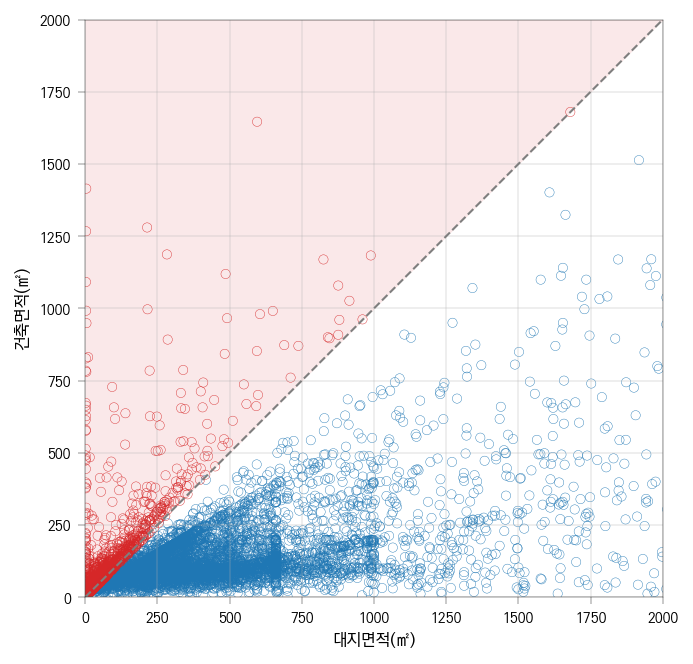

In [113]:
sampled = stratified_sample(df, "건축_면적_이상", n=10_000, min_per_stratum=1_000)

# Scatterplot of "대지_면적(㎡)" vs "건축_면적(㎡)"
plt.figure(figsize=(5, 5))
colors = sampled["건축_면적_이상"].map({True: "tab:red", False: "tab:blue"})
plt.scatter(
    sampled["대지_면적(㎡)"],
    sampled["건축_면적(㎡)"],
    edgecolors=colors,
    facecolors="none",
    s=20,
)

max_val = sampled["건축_면적(㎡)"].max()
max_val = 2000
plt.xlim(0, max_val)
plt.ylim(0, max_val)

# 45-degree line
plt.plot([0, max_val], [0, max_val], color="tab:gray", linestyle="--", linewidth=1)

# Shade area above the 45-degree line
plt.fill_between(
    [0, max_val],
    [max_val, max_val],
    [0, max_val],
    color="tab:red",
    alpha=0.10,
    zorder=0,
)
# plt.xscale("log")
# plt.yscale("log")

plt.gca().set_aspect("equal")
plt.xlabel("대지면적(㎡)")
plt.ylabel("건축면적(㎡)")
# plt.title("대지 면적과 건축 면적 산점도")
plt.grid(True)

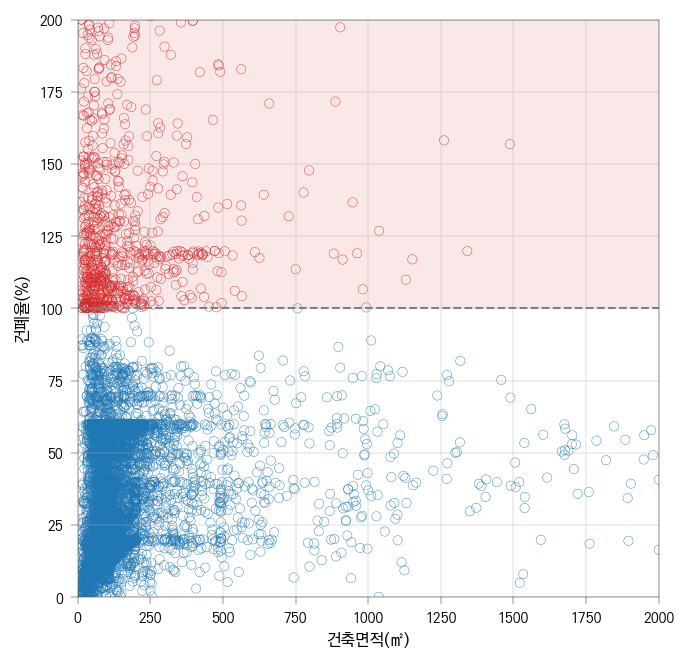

In [122]:
df["건폐율_이상"] = df["건폐_율(%)"] > 100
sampled = stratified_sample(df, "건폐율_이상", n=10_000, min_per_stratum=1_000)

plt.figure(figsize=(5, 5))
colors = sampled["건폐율_이상"].map({True: "tab:red", False: "tab:blue"})
plt.scatter(
    sampled["건축_면적(㎡)"],
    sampled["건폐_율(%)"],
    edgecolors=colors,
    facecolors="none",
    s=20,
)
max_xval = 2000
max_yval = 200
plt.xlim(0, max_xval)
plt.ylim(0, max_yval)

# line
plt.plot([0, max_xval], [100, 100], color="tab:gray", linestyle="--", linewidth=1)

# Shade area above the line
plt.fill_between(
    [0, max_xval],
    [100, 100],
    [max_yval, max_yval],
    color="tab:red",
    alpha=0.10,
    zorder=0,
)

plt.xlabel("건축면적(㎡)")
plt.ylabel("건폐율(%)")
plt.grid(True)

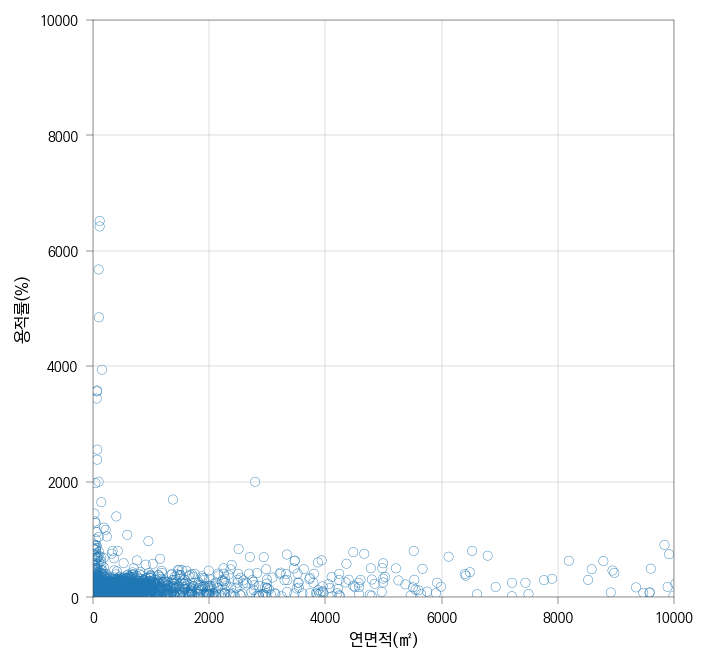

In [ ]:
df["건폐율_이상"] = df["건폐_율(%)"] > 100
sampled = stratified_sample(df, "건폐율_이상", n=10_000, min_per_stratum=1_000)

plt.figure(figsize=(5, 5))
colors = sampled["건폐율_이상"].map({True: "tab:red", False: "tab:blue"})
plt.scatter(
    sampled["연면적(㎡)"],
    sampled["용적_률(%)"],
    # edgecolors=colors,
    edgecolors="tab:blue",
    facecolors="none",
    s=20,
)
max_xval = 10_000
max_yval = 10_000
plt.xlim(0, max_xval)
plt.ylim(0, max_yval)

# line
# plt.plot([0, max_xval], [100, 100], color="tab:gray", linestyle="--", linewidth=1)

# Shade area above the line
# plt.fill_between(
#     [0, max_xval],
#     [100, 100],
#     [max_yval, max_yval],
#     color="tab:red",
#     alpha=0.10,
#     zorder=0,
# )

plt.xlabel("연면적(㎡)")
plt.ylabel("용적률(%)")
plt.grid(True)

In [ ]:
# from sklearn import svm
from sklearn.covariance import EllipticEnvelope
from sklearn.ensemble import IsolationForest
from sklearn.kernel_approximation import Nystroem
from sklearn.neighbors import LocalOutlierFactor
from sklearn.pipeline import make_pipeline

from sklearn.model_selection import train_test_split

from sklearn.inspection import DecisionBoundaryDisplay


In [200]:
sampled = df.sample(n=10_000, replace=False, random_state=1106)
X = sampled[["연면적(㎡)", "용적_률(%)"]].dropna().values
X[:, 0] = np.log1p(X[:, 0])  # log transform 연면적
# X_train, X_test = train_test_split(X, test_size=0.2, random_state=1106)

clf = LocalOutlierFactor()
y_pred = clf.fit_predict(X)
unique, counts = np.unique(y_pred, return_counts=True)
print(dict(zip(unique, counts)))


{np.int64(-1): np.int64(330), np.int64(1): np.int64(6559)}


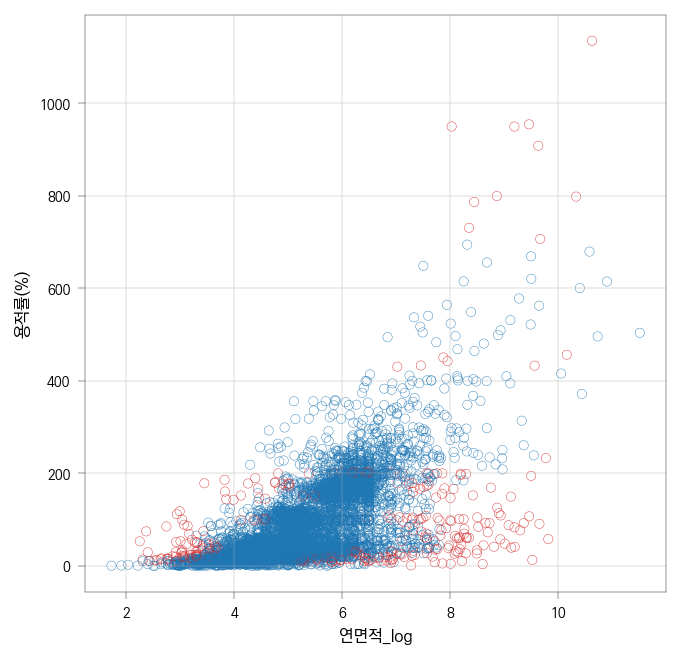

: 

In [ ]:
plt.figure(figsize=(5, 5))
colors = np.where(y_pred == -1, "tab:red", "tab:blue")
# disp = DecisionBoundaryDisplay.from_estimator(
#     clf,
#     X,
#     response_method="decision_function",
# alpha=0.5,
# ax=plt.gca(),
# )
plt.scatter(
    X[:, 0],
    X[:, 1],
    edgecolors=colors,
    facecolors="none",
    s=20,
)
# max_xval = 10_000
# max_yval = 10_000
# plt.xlim(0, max_xval)
# plt.ylim(0, max_yval)
plt.xlabel("연면적_log")
plt.ylabel("용적률(%)")
plt.grid(True)

(1000, 2) float64


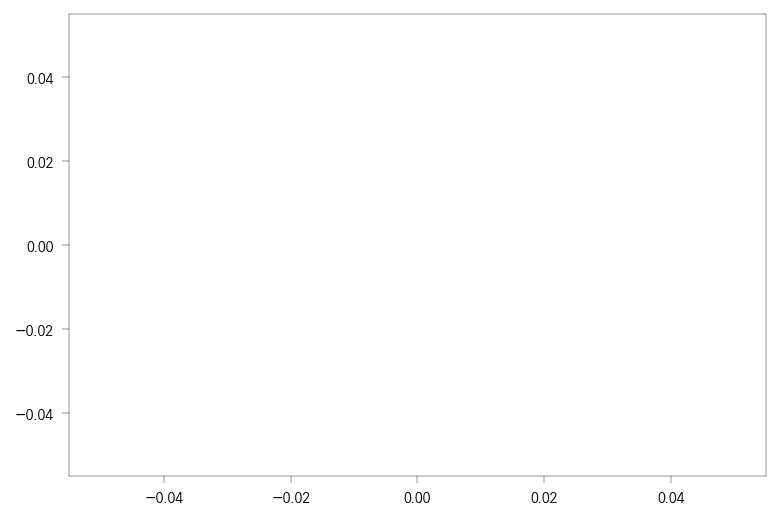

In [196]:
sampled = df.sample(n=1_000, replace=False, random_state=1106)
X = sampled[["연면적(㎡)", "용적_률(%)"]].values
X_train, X_test = train_test_split(X, test_size=0.2, random_state=1106)

clf = IsolationForest(random_state=1106)
clf.fit(X_train)

print(X.shape, X.dtype)


disp = DecisionBoundaryDisplay.from_estimator(
    clf,
    X,
    alpha=0.5,
)

(280, 2) float64


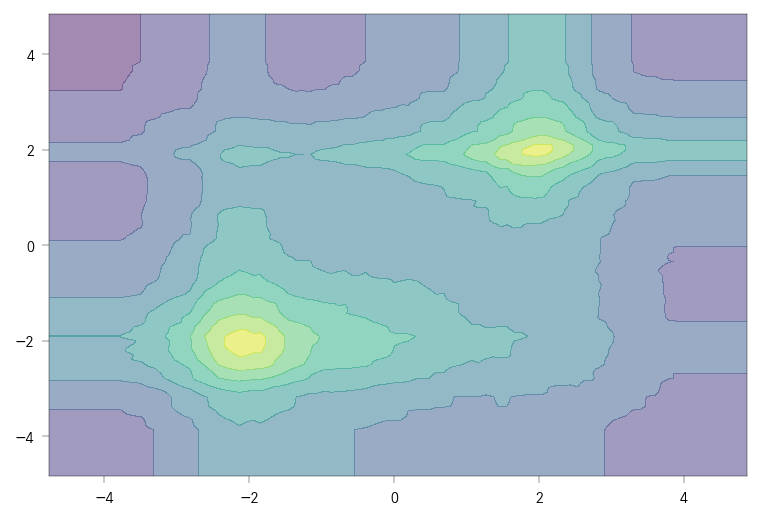

In [195]:
import numpy as np

from sklearn.model_selection import train_test_split

n_samples, n_outliers = 120, 40
rng = np.random.RandomState(0)
covariance = np.array([[0.5, -0.1], [0.7, 0.4]])
cluster_1 = 0.4 * rng.randn(n_samples, 2) @ covariance + np.array([2, 2])  # general
cluster_2 = 0.3 * rng.randn(n_samples, 2) + np.array([-2, -2])  # spherical
outliers = rng.uniform(low=-4, high=4, size=(n_outliers, 2))

X = np.concatenate([cluster_1, cluster_2, outliers])
print(X.shape, X.dtype)

X_train, X_test = train_test_split(X, random_state=42)

from sklearn.ensemble import IsolationForest

clf = IsolationForest(max_samples=100, random_state=0)
clf.fit(X_train)

disp = DecisionBoundaryDisplay.from_estimator(
    clf,
    X,
    response_method="decision_function",
    alpha=0.5,
)
# scatter = disp.ax_.scatter(X[:, 0], X[:, 1], s=20, edgecolor="k")
# disp.ax_.set_title("Path length decision boundary \nof IsolationForest")
# plt.axis("square")
# plt.colorbar(disp.ax_.collections[1])
# plt.show()